In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["MKL_CBWR"] = "COMPATIBLE"
os.environ["ATEN_CPU_CAPABILITY"] = "avx2"
os.environ["OMP_NUM_THREADS"] = os.environ["MKL_NUM_THREADS"] = os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["NPY_DISABLE_CPU_FEATURES"] = "AVX512F AVX512CD AVX512_KNL AVX512_KNM AVX512_SKX AVX512_CLX AVX512_CNL AVX512_ICL AVX512_SPR"
os.environ["OPENBLAS_CORETYPE"] = "Haswell"

import sys
sys.path.append("..")

# Example Alignment on Spatiotemporal Mouse Embryo

We provide an example alignment on two spatiotemporal mouse embryo slices -- `E9.5` and `E10.5` -- from Chen et al '22 (link: https://pubmed.ncbi.nlm.nih.gov/35512705/).

In particular, we show the alignment of `MGW` on the public `E9.5_E1S1.MOSTA.h5ad` and `E10.5_E1S1.MOSTA.h5ad` files. A key point is that no fused FGW feature information is used, so this alignment is treated as if the data were "multimodal."

In [2]:
# ============================================================
# M-GW: Pairwise Alignment of Spatiotemporal Mouse Embryo Slices
# ============================================================

import scanpy as sc
import anndata as ad
import numpy as np, torch, scipy.sparse as sp
from mgw import util, models, plotting, geometry
from mgw import pullback_metric_field, knn_graph
from mgw.gw import solve_gw_ott
import importlib
import matplotlib.pyplot as plt
import os
from mgw.config import DATA_DIR

# ----------------------------
# Runtime & device setup
# ----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(torch.float64)
print("Device:", device)

# ----------------------------
# Input files & parameters
# ----------------------------
filehandles_embryo_adata = [
    DATA_DIR / 'mouse_embryo/E9.5_E1S1.MOSTA.h5ad',
    DATA_DIR / 'mouse_embryo/E10.5_E1S1.MOSTA.h5ad'
]
timepoints = ['E9.5', 'E10.5']

# Embedding / network parameters
PCA_comp   = 30
knn_k      = 12
geodesic_eps = 0.01

gw_params = dict(verbose=True, inner_maxit=3000, outer_maxit=3000,
                 inner_tol=1e-7, outer_tol=1e-7, epsilon=1e-4)

save_dir = DATA_DIR / "mouse_embryo/alignments"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. Load datasets and prepare
# ============================================================
print('Loading AnnData slices...')
adatas = []
for i, fh in enumerate(filehandles_embryo_adata):
    adata = sc.read_h5ad(fh)
    adata.X = adata.layers['count']
    adata.obs['timepoint'] = [timepoints[i]] * adata.shape[0]
    adatas.append(adata)

# Intersect genes across all slices
common_genes = sorted(set.intersection(*[set(a.var_names) for a in adatas]))
adatas = [a[:, common_genes] for a in adatas]
print(f"Common genes: {len(common_genes)}")


Device: cpu
Loading AnnData slices...
Common genes: 24040


In [3]:
from mgw import metrics
from mgw import mgw as mgw
from scipy.spatial.distance import cdist

ad1, ad2 = adatas[0], adatas[1]
tp1, tp2 = timepoints[0], timepoints[1]

print(f"\n--- Aligning {tp1} → {tp2} ---")

# Normalization, log1p, PCA
joint = ad.concat([ad1, ad2], join='inner')

sc.pp.normalize_total(joint)
sc.pp.log1p(joint)
sc.pp.pca(joint, n_comps=PCA_comp)

# Split back into slices
A = joint[joint.obs['timepoint'] == tp1].copy()
B = joint[joint.obs['timepoint'] == tp2].copy()

# ========================================================
# (a) Feature preprocessing (PCA + CCA "feeler")
# ========================================================

pre = mgw.mgw_preprocess(
        A, B,
        PCA_comp=30,
        CCA_comp=3,
        use_cca_feeler=True,
        use_pca_X=True,
        use_pca_Z=True,
        log1p_X=True,
        log1p_Z=True,
        verbose=True,
        feature_only=False,
        spatial_only=True,
        rep_norm="zscore",
)



--- Aligning E9.5 → E10.5 ---


/var/folders/yt/z9v0j0ld4ln5xtzsr2196m6w0000gn/T/ipykernel_92808/781299413.py:11: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  joint = ad.concat([ad1, ad2], join='inner')


[mgw.pre] PCA/raw shapes: X=(5913, 30)  Z=(18408, 30)
[mgw.pre] CCA feeler: PCA → small GW (fused) → barycentric → CCA
Using precomputed PCA (30 comps).
Using precomputed PCA (30 comps).
Feature shapes -> X: (5913, 30) Z: (18408, 30)
Feeler GW sizes: X-side 5913, Z-side 8000
Solving feeler feature alignment.
Computing CCA Components
CCA dims: 3  (applied to full sets)


In [4]:
PCA_component = 30
CCA_component = 3

PHI_ARC = (128,256,256,128)
KNN_K= 12
DEFAULT_GW_PARAMS = dict(verbose=True, inner_maxit=3000, outer_maxit=3000, inner_tol=1e-7,   outer_tol=1e-7,   epsilon=1e-4)
DEFAULT_LR = 1e-3
DEFAULT_EPS = 1e-2
DEFAULT_ITER = 20_000
SEED = 1


In [5]:
EXP_PATH = None #specify the path to save your trained phi psi model (None: retrain without caching)
EXP_TAG = f'ME_CCA_seed{SEED}' #specify the name of your experiment

[mgw.core] device=cpu dtype=torch.float64
[mgw.core] dims: E=2, F_M=3, F_N=3
[mgw.core] seed=1
[mgw.core] deterministic training (fused Adam, deterministic kernels)
[mgw.core] training φ, ψ
[train_phi] step=1000 loss=0.163923
[train_phi] step=2000 loss=0.141438
[train_phi] step=3000 loss=0.130407
[train_phi] step=4000 loss=0.122905
[train_phi] step=5000 loss=0.117872
[train_phi] step=6000 loss=0.118313
[train_phi] step=7000 loss=0.107503
[train_phi] step=8000 loss=0.101160
[train_phi] step=9000 loss=0.096788
[train_phi] step=10000 loss=0.109220
[train_phi] step=11000 loss=0.098226
[train_phi] step=12000 loss=0.087394
[train_phi] step=13000 loss=0.085394
[train_phi] step=14000 loss=0.082632
[train_phi] step=15000 loss=0.082176
[train_phi] step=16000 loss=0.077763
[train_phi] step=17000 loss=0.077217
[train_phi] step=18000 loss=0.076441
[train_phi] step=19000 loss=0.074226
[train_phi] step=20000 loss=0.073118
[train_phi] step=1000 loss=0.591779
[train_phi] step=2000 loss=0.567291
[train_

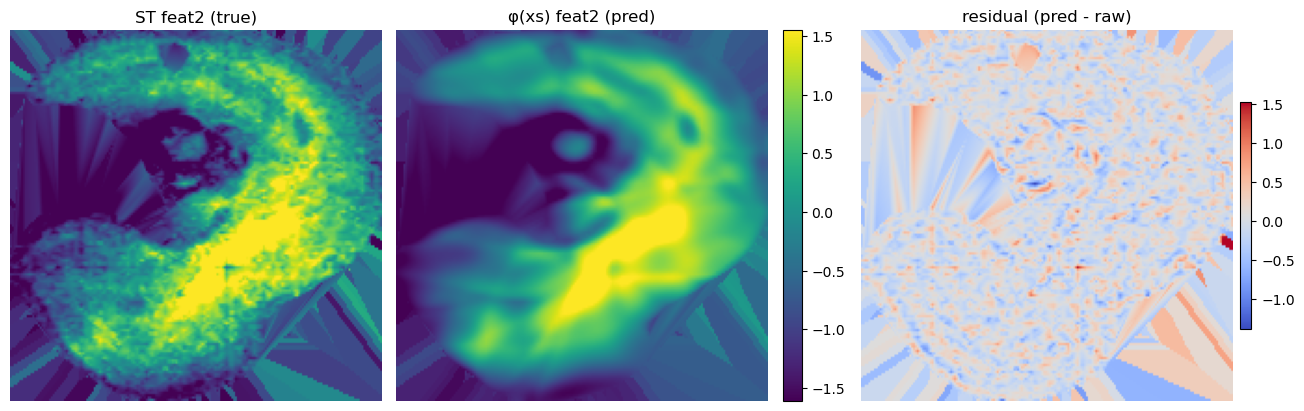

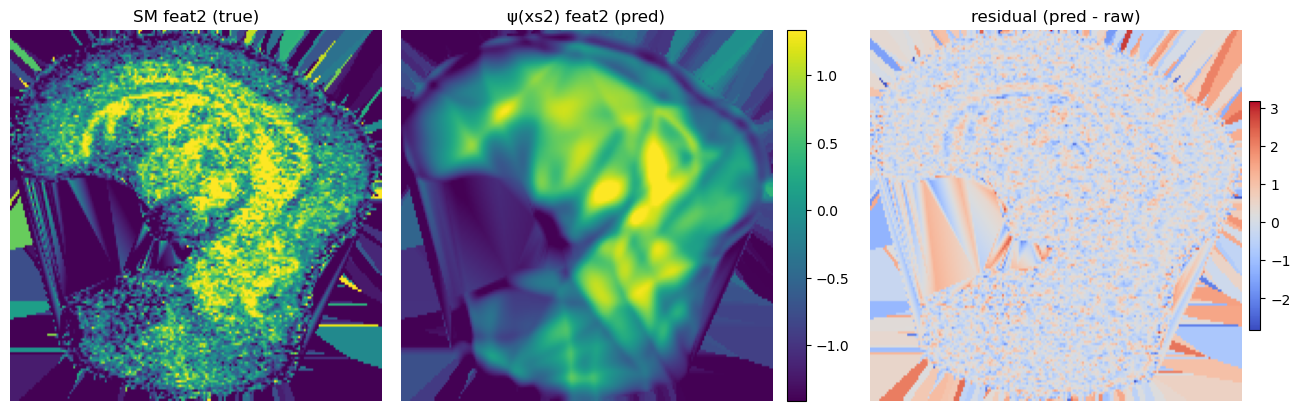

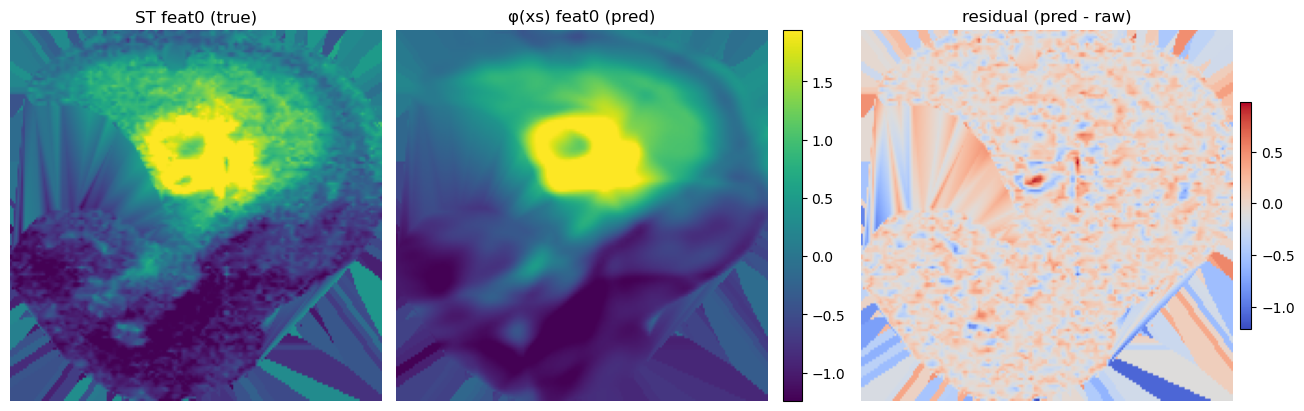

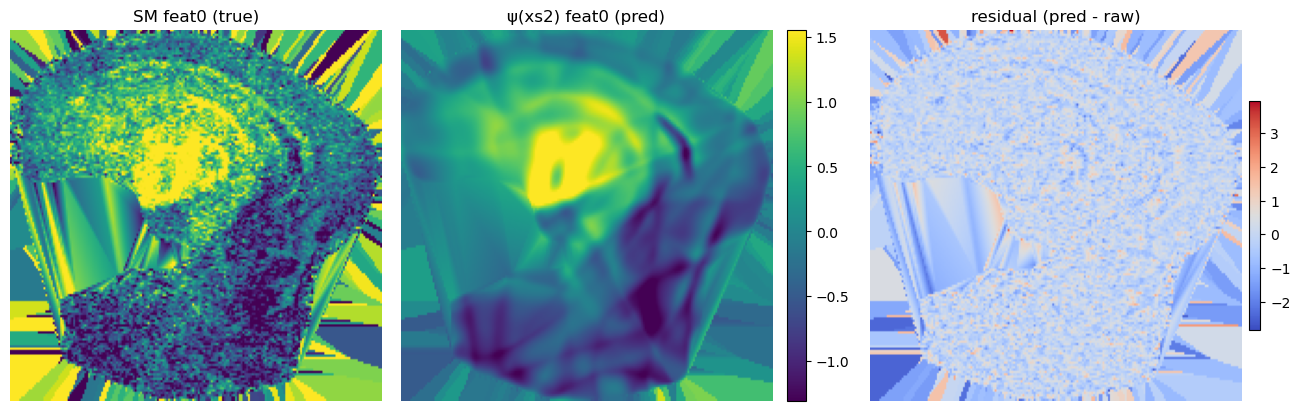

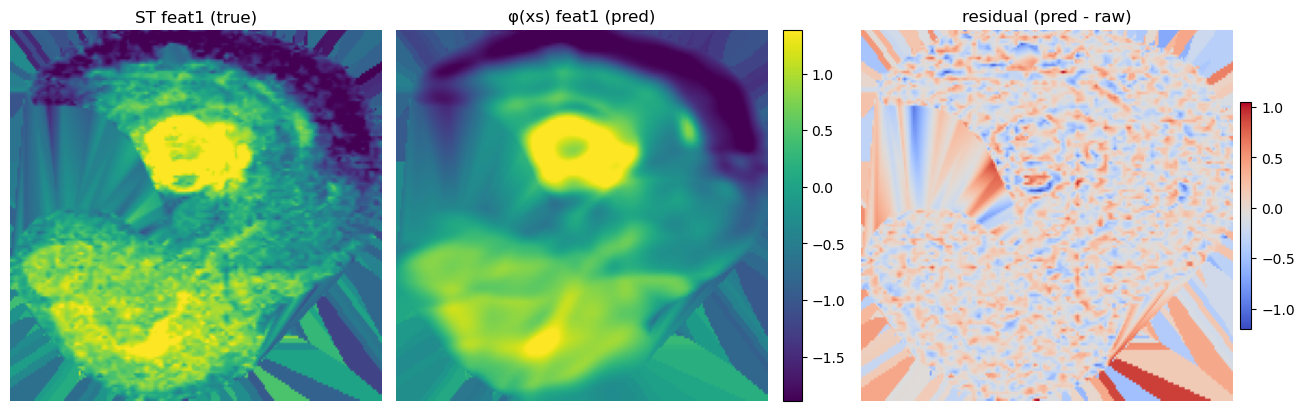

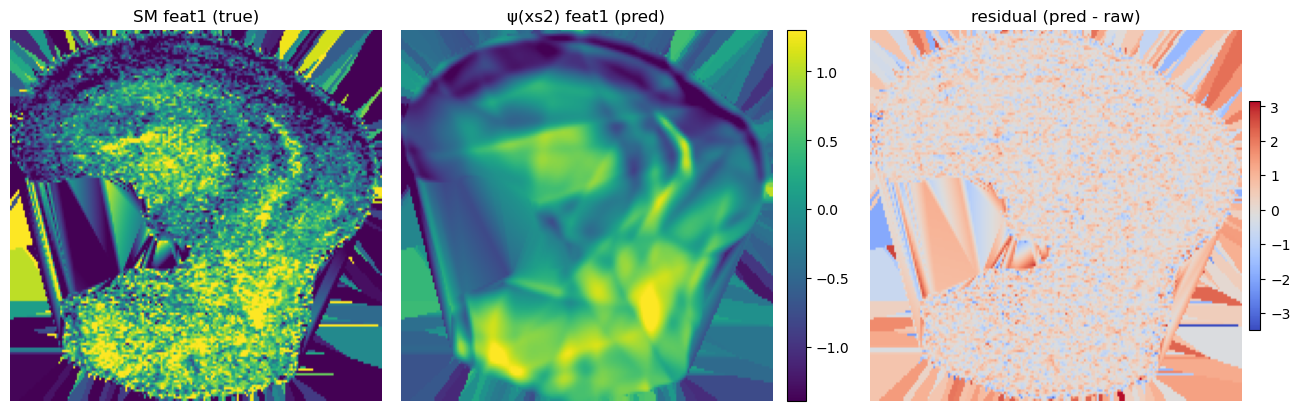

[mgw.core] pullback metrics & geodesics
Rescaling Jacobians by 256.4659501458385.
Rescaling Jacobians by 347.598657370003.
[mgw.core] cost matrices: d^2 (cost_p=2)
[mgw.core] solving GW with {'verbose': True, 'inner_maxit': 3000, 'outer_maxit': 3000, 'inner_tol': 1e-07, 'outer_tol': 1e-07, 'epsilon': 0.0001}
[mgw.core] coupling: shape=(5913, 18408), mass=0.999985


In [6]:

out = mgw.mgw_align_core(
        pre,
        widths=PHI_ARC,
        lr=DEFAULT_LR,
        niter=DEFAULT_ITER,
        knn_k=KNN_K,
        geodesic_eps=DEFAULT_EPS,
        save_dir=EXP_PATH, 
        tag=EXP_TAG, 
        verbose=True,
        plot_net=True,
        gw_params = DEFAULT_GW_PARAMS,
        seed=SEED,
        deterministic=True,
        n_restarts=1,
    )


# We can plot the associated alignment after rigid-transformation into a common frame with Procrustes.

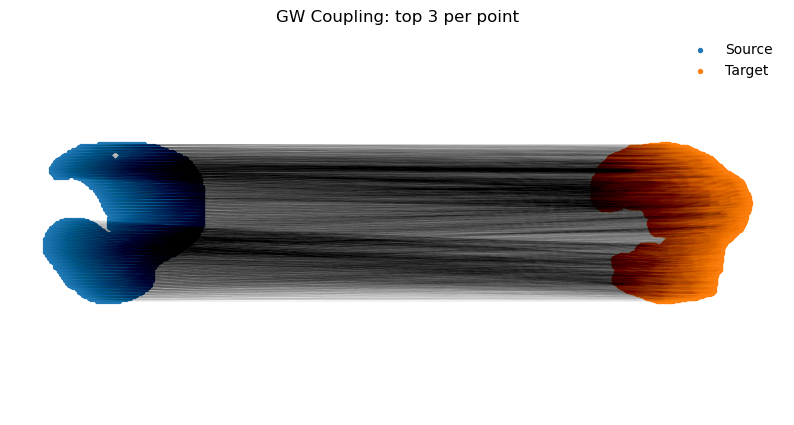

In [7]:

xs = out["xs"]
xs2 = out["xs2"]
P = out["P"]
xs_aligned, xt_aligned, R, tvec = plotting.procrustes_from_coupling(xs, xs2, P)
plotting.plot_alignment_lines_dense(xs, xs2, P, alpha=0.01)


# We can check the orientation of the alignment.

In [8]:
Y = (P @ xs2) / P.sum(1, keepdims=True)
U, _, Vt = np.linalg.svd((xs - xs.mean(0)).T @ (Y - Y.mean(0)))
print(f"orientation det = {np.linalg.det(U @ Vt):+.0f}")

PAPER_P = '/scratch/gpfs/BRAPHAEL/ph3641/mgw/ME_Alignments/P_E9.5_E10.5.npz'
if os.path.isfile(PAPER_P):
    P_ref = sp.load_npz(PAPER_P)
    Y_ref = np.asarray(P_ref @ xs2) / np.asarray(P_ref.sum(1))
    print(f"distance to paper MGW map = {np.sqrt(((Y - Y_ref) ** 2).sum(1).mean()):.3f}")

orientation det = +1
distance to paper MGW map = 0.072


# We can also view the alignment as two tilted layers joined by the coupling's peak links.

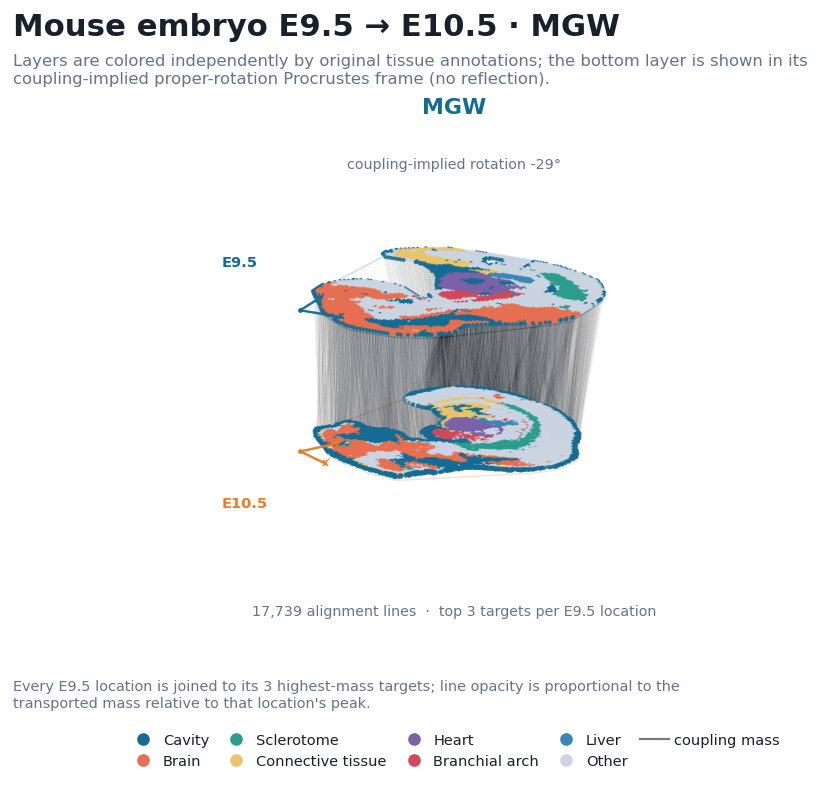

In [9]:
from mgw import align_vis

top, bottom, _ = align_vis.coarsen_to_shared_annotations(A.obs["annotation"].astype(str).to_numpy(),
                                                         B.obs["annotation"].astype(str).to_numpy(), max_classes=7)
_ = align_vis.plot_tilted_alignment(
    A.obsm["spatial"], B.obsm["spatial"], top, bottom, P,
    dataset_title=f"Mouse embryo {tp1} → {tp2} · MGW", top_name=tp1, bottom_name=tp2,
    label_description="original tissue annotations", k_per_point=3)

# One can also project the annotations through the alignment to find the `mgw` predicted clusters.

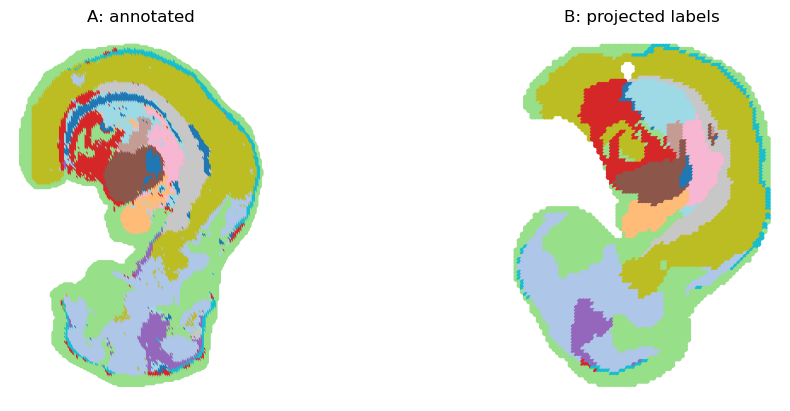

In [10]:

A_labels = plotting._labels_or_cluster(A, key="annotation")
B_labels = plotting._labels_or_cluster(B, key="annotation")

A_pred, A_conf, _ = plotting.project_labels_via_P(P.T, B_labels, direction="A_to_B")
plotting.plot_projected_labels(B.obsm['spatial'], A.obsm['spatial'],
                                  B_labels, A_pred, conf_thresh=0.5, s=10)
